# Cape Cauldron coherent vortices

The Cape Cauldron is the Agulhas-ring corridor south-west of South Africa.
Haller & Beron-Vera (2013,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)) found
coherent Lagrangian vortices there with the same $\eta_\lambda$ construction
this notebook uses.

The FTLE ridges in `cabo_verde_ftle` mark hyperbolic stretching. A coherent
Lagrangian vortex is a different structure, a region that stays together as it
advects, bounded by a material curve that stretches uniformly.
Haller (2015, §5.1 / Table 1, row "Shear",
[doi:10.1146/annurev-fluid-010313-141322](https://doi.org/10.1146/annurev-fluid-010313-141322))
builds such curves from the same Cauchy–Green tensor
$C = (\nabla F)^\top \nabla F$, eigenpairs $C\xi_i = \lambda_i \xi_i$,
$0 < \lambda_1 \le \lambda_2$. A *shear line* is tangent everywhere to
(Eq. 11)

$$
\eta^{\pm} = \sqrt{\frac{\sqrt{\lambda_2}}{\sqrt{\lambda_1}+\sqrt{\lambda_2}}}\,\xi_1
  \;\pm\; \sqrt{\frac{\sqrt{\lambda_1}}{\sqrt{\lambda_1}+\sqrt{\lambda_2}}}\,\xi_2 \,.
$$

A closed shear line is an **elliptic LCS**, and the outermost member of a nested
family of closed shear lines is the boundary of a coherent Lagrangian vortex.
Eq. 11 keeps a material curve's arc length fixed under an area-preserving
flow. The Cape Cauldron surface flow is not area-preserving over 30 days, so
this notebook uses the $\lambda$-generalisation instead (Haller & Beron-Vera 2013,
Eq. 14,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)):

$$
\eta_\lambda^{\pm} = \sqrt{\frac{\lambda_2 - \lambda^2}{\lambda_2 - \lambda_1}}\,\xi_1
  \;\pm\; \sqrt{\frac{\lambda^2 - \lambda_1}{\lambda_2 - \lambda_1}}\,\xi_2 \,,
$$

well defined only where $\lambda_1 < \lambda^2 < \lambda_2$. It satisfies
$|\nabla F\,\eta_\lambda| = \lambda$ at every point, so a curve tangent to
it has its arc length multiplied by $\lambda$ over the window, and a closed
orbit of $\eta_\lambda$ is a uniformly stretching material loop. Eq. 11 is
Eq. 14 at $\lambda = 1$ where the flow is area-preserving, so
$\lambda_1\lambda_2 = 1$. This notebook scans $\lambda$ from 0.8 to 2.0 and
both signs, since the boundary can show up at any of them.

Detection follows Haller & Beron-Vera (2013,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)). A short
Poincaré section runs through a candidate centre, $\eta_\lambda$ lines are
launched along it and integrated to their first return, and the return map
$s \mapsto P(s)$ is read off the section. A fixed point $P(s) = s$ is a
closed orbit.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.path import Path as MplPath
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4
from scipy.interpolate import RegularGridInterpolator

from lcs_parcels import NeighborSeedGrid
from lcs_parcels.grids import _M_PER_DEG, _separation_m
from lcs_parcels.tensorlines import _step_lonlat_by_meters

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_60785/590446562.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

The local file that `get_data` writes.

In [2]:
currents = xr.open_dataset("data/cape_cauldron_currents_hourly.nc").load()
currents

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 1489, depth: 1, latitude: 385, longitude: 433)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2025-05-31 ... 2025-08-01
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -52.0 -51.92 -51.83 ... -20.08 -20.0
  * longitude  (longitude) float32 2kB -6.0 -5.917 -5.833 ... 29.83 29.92 30.0
Data variables:
    uo         (time, depth, latitude, longitude) float32 993MB 0.1821 ... nan
    vo         (time, depth, latitude, longitude) float32 993MB 0.2285 ... nan
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     hourly mean fields from Global Ocean Physics A...
    copernicusmarine_version:  2.4.1

## Parcels v4 field set

`copernicusmarine_to_sgrid` tags the CMEMS A-grid with SGRID metadata, and
`from_sgrid_conventions` wraps it as a spherical `FieldSet`.

In [3]:
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed grid and window

A box across the Cape Cauldron at 1/25 degree, released on 2025-06-01 and read
at 30 days. An Agulhas ring up to 300 km across turns once in roughly 7 to 12
days, so the 30-day window covers a few revolutions.

Only the forward flow map is needed, since a vortex boundary is a property of
one time window, not of the forward/backward pair `cabo_verde_lcs` uses for
repelling/attracting duality.

The gradient is differenced across neighbouring grid points 1/25 degree apart.

In [4]:
t0 = np.datetime64("2025-06-01")
T = np.timedelta64(30, "D")
resolution_deg = 1 / 25
seed_lon, seed_lat = (2.0, 22.0), (-44.0, -28.0)

lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. The kernel sets `StatusCode.EndofLoop`
rather than `StatusCode.Delete`, because deleting shrinks the particle
array and breaks the alignment with the seed order.

In [5]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

One particle set, run over the whole window, with the final positions read
back into the flow map.

In [6]:
lon, lat = seed.to_parcels_pset()
z = np.full(len(lon), z_surface)
pset = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)

In [7]:
forward = seed.pset_to_flowmap(lon=pset.x, lat=pset.y, t0=t0, t1=t0 + T)
forward

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2025-06-01T00:00:00, T +30.0 days>

Particles lost to land or to the domain edge.

In [8]:
int(np.isnan(np.asarray(pset.x)).sum())

24500

## Eigendecomposition and FTLE

`cg_eigen` carries $\lambda_1,\lambda_2$ and $\xi_1,\xi_2$ together. `ftle`
is the backdrop the candidate centres and the closed orbits are shown
against below.

In [9]:
eigen = forward.cg_eigen()
eigen

<xarray.Dataset> Size: 13MB
Dimensions:   (i: 501, j: 401, eig: 2, comp: 2)
Coordinates:
  * i         (i) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499 500
  * j         (j) int64 3kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399 400
    lon_grid  (i, j) float64 2MB 2.0 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid  (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.08 -28.04 -28.0
  * eig       (eig) int64 16B 0 1
  * comp      (comp) <U1 8B 'x' 'y'
    t0        datetime64[s] 8B 2025-06-01
    T         timedelta64[s] 8B 30 days
Data variables:
    lambda    (i, j, eig) float64 3MB nan nan nan nan nan ... nan nan nan nan
    xi        (i, j, comp, eig) float64 6MB nan nan nan nan ... nan nan nan nan

In [10]:
ftle = forward.ftle()
ftle

<xarray.DataArray 'ftle' (i: 501, j: 401)> Size: 2MB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan, 1.02784885e-06, 1.08541768e-06, ...,
        1.16775882e-06, 6.81639315e-07,            nan],
       [           nan, 1.05254139e-06, 1.02470785e-06, ...,
        9.48960496e-07, 6.39084755e-07,            nan],
       ...,
       [           nan, 8.05394595e-07, 5.21071623e-07, ...,
                   nan,            nan,            nan],
       [           nan, 8.20633171e-07, 4.72756821e-07, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], shape=(501, 401))
Coordinates:
  * i         (i) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499 500
  * j         (j) int64 3kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399 400
    lon_grid  (i, j) float64 2MB 2.0 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid  (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.08 -28.04 -28.0
    t0        datetime64[s] 8B 2025-06-01
    T         timedelta64[s] 8B 30 days
Attributes:
    long_name:  finite-time Lyapunov exponent
    units:      1/s

## The $\eta_\lambda$ tangent field

`shrink_lines` traces $\xi_1$ and takes no caller-supplied tangent field, so
the $\eta_\lambda$ field is built here. It follows the same scheme as the
library tracer, interpolating $C$ itself rather than the eigenvectors and
re-diagonalising at every evaluation.

$\xi_1$ and $\xi_2$ each carry a sign that `eigh` picks arbitrarily, and
flipping $\xi_2$ alone turns $\eta^+$ into $\eta^-$. The two signs are tied
together below so the two branches stay apart.

In [11]:
lon_grid_axis = forward.lon_grid.isel(j=0).values
lat_grid_axis = forward.lat_grid.isel(i=0).values
CG_grid = forward.cauchy_green().transpose("i", "j", "row", "col").values
tensor_interp = RegularGridInterpolator(
    (lon_grid_axis, lat_grid_axis), CG_grid, bounds_error=False, fill_value=np.nan
)


def eta_lambda_tangent(lon, lat, heading, *, lam, sign, tensor_interp):
    """Unit eta_lambda^{sign} (Haller & Beron-Vera 2013, Eq. 14, https://doi.org/10.1017/jfm.2013.391) at each point.

    NaN wherever off-grid, in a NaN cell, or lam**2 does not sit strictly
    inside (lambda_1, lambda_2), the well-definedness condition for eta_lambda.
    """
    C = tensor_interp(np.column_stack([lon, lat]))
    terminated = ~np.isfinite(C).all(axis=(1, 2))
    eigenvalues, eigenvectors = np.linalg.eigh(
        np.where(terminated[:, None, None], np.eye(2), C)
    )
    lam1, lam2 = np.maximum(eigenvalues[:, 0], 0.0), eigenvalues[:, 1]
    well_defined = (lam1 < lam**2) & (lam**2 < lam2)
    terminated = terminated | ~well_defined
    denom = np.maximum(lam2 - lam1, 1e-30)
    a = np.sqrt(np.clip((lam2 - lam**2) / denom, 0.0, 1.0))
    b = np.sqrt(np.clip((lam**2 - lam1) / denom, 0.0, 1.0))
    xi1 = eigenvectors[:, :, 0]
    # Taking xi_2 as xi_1 turned 90 degrees counter-clockwise ties the two
    # eigenvector signs together, so eta^+ and eta^- stay distinct.
    xi2 = np.column_stack([-xi1[:, 1], xi1[:, 0]])
    eta = a[:, None] * xi1 + sign * b[:, None] * xi2
    # Negating xi_1 negates xi_2 with it, so eta is fixed up to one overall
    # sign, and orienting it to the running heading stays inside one branch.
    eta[np.sum(eta * heading, axis=1) < 0] *= -1
    eta[terminated] = np.nan
    return eta

## RK2 tracer

Marches $\eta_\lambda$ one direction from a set of launch points with the
midpoint (RK2) scheme `shrink_lines` uses. The spherical step
`_step_lonlat_by_meters` is imported from `lcs_parcels.tensorlines`, where it
is private, since the package exposes no public tangent-field stepper.

In [12]:
def trace_eta_lines(*, lon_0, lat_0, lam, sign, step_m, n_steps, tensor_interp):
    lon = np.asarray(lon_0, dtype=float).ravel().copy()
    lat = np.asarray(lat_0, dtype=float).ravel().copy()
    heading = eta_lambda_tangent(
        lon,
        lat,
        np.ones((lon.size, 2)),
        lam=lam,
        sign=sign,
        tensor_interp=tensor_interp,
    )
    dead = ~np.isfinite(heading).all(axis=1)
    lon[dead], lat[dead] = np.nan, np.nan
    track_lon, track_lat = [lon.copy()], [lat.copy()]
    for _ in range(n_steps):
        direction = eta_lambda_tangent(
            lon, lat, heading, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        mid_lon, mid_lat = _step_lonlat_by_meters(
            lon, lat, 0.5 * direction, step_m=step_m
        )
        mid_direction = eta_lambda_tangent(
            mid_lon, mid_lat, direction, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        lon, lat = _step_lonlat_by_meters(lon, lat, mid_direction, step_m=step_m)
        heading = mid_direction
        track_lon.append(lon.copy())
        track_lat.append(lat.copy())
    return np.array(track_lon), np.array(track_lat)  # (n_steps + 1, n)

## Where $\eta_\lambda$ is well defined, at $\lambda = 1$

$\eta_1$ needs $\lambda_1 < 1 < \lambda_2$, so a neighbourhood has to be
stretched in one eigendirection and contracted in the other. Where it is not,
there is no direction of stretch factor 1 and a traced line ends.

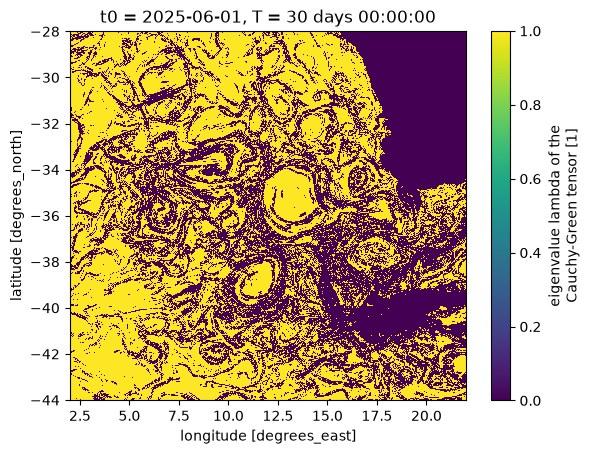

In [13]:
lambda1 = eigen["lambda"].isel(eig=0)
lambda2 = eigen["lambda"].isel(eig=1)
well_defined = (lambda1 < 1.0) & (1.0 < lambda2)
well_defined.plot.pcolormesh(x="lon_grid", y="lat_grid")

## How far from area-preserving

$\sqrt{\lambda_1\lambda_2} = |\det \nabla F|$ is the area change over the
window, so the spread of the quantiles below says how far this flow is from
area-preserving. The sweep scans $\lambda$ from 0.8 to 2.0 rather than
fixing $\lambda = 1$.

In [14]:
det_grad_F = np.sqrt(lambda1 * lambda2)
det_grad_F.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

<xarray.DataArray 'lambda' (quantile: 5)> Size: 40B
array([1.72273788e-01, 9.35690458e-01, 4.95873883e+00, 5.15097163e+01,
       6.74995378e+02])
Coordinates:
  * quantile  (quantile) float64 40B 0.05 0.25 0.5 0.75 0.95
Attributes:
    long_name:  eigenvalue lambda of the Cauchy-Green tensor
    units:      1

## Candidate vortex centres

Haller & Beron-Vera (2013,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)) place
their sections through singularities of $C$, the points where
$\lambda_1 = \lambda_2$ and the eigendirections stop being defined.
Candidate centres are therefore windowed minima of $\lambda_2/\lambda_1$.

`find_centres` below is the `ftle_ridge_seeds` windowed-extremum trick inverted
to a minimum, plus a guard keeping a centre 50 km from the domain edge and from
any NaN (land) cell, where the tensor is unreliable. The window is 200 km, so a
genuine core is not split into several spurious local minima.

In [15]:
def find_centres(field, *, window_m, edge_m):
    lon_grid, lat_grid = field["lon_grid"], field["lat_grid"]
    dx, _ = _separation_m(
        lon_a=lon_grid.shift(i=1),
        lat_a=lat_grid.shift(i=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    _, dy = _separation_m(
        lon_a=lon_grid.shift(j=1),
        lat_a=lat_grid.shift(j=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    spacing_i, spacing_j = float(np.abs(dx).median()), float(np.abs(dy).median())
    cells_i = max(
        1, round(window_m / spacing_i) - (round(window_m / spacing_i) % 2 == 0)
    )
    cells_j = max(
        1, round(window_m / spacing_j) - (round(window_m / spacing_j) % 2 == 0)
    )
    local_min = field.rolling(i=cells_i, j=cells_j, center=True, min_periods=1).min()
    is_centre = field <= local_min

    edge_cells_i = int(np.ceil(edge_m / spacing_i))
    edge_cells_j = int(np.ceil(edge_m / spacing_j))
    ni, nj = field.sizes["i"], field.sizes["j"]
    valid_window = (
        field.notnull()
        .astype(float)
        .rolling(
            i=2 * edge_cells_i + 1, j=2 * edge_cells_j + 1, center=True, min_periods=1
        )
        .min()
    )
    i_idx, j_idx = (
        xr.DataArray(np.arange(ni), dims="i"),
        xr.DataArray(np.arange(nj), dims="j"),
    )
    near_edge = (
        (i_idx < edge_cells_i)
        | (i_idx >= ni - edge_cells_i)
        | (j_idx < edge_cells_j)
        | (j_idx >= nj - edge_cells_j)
    )
    keep = is_centre & field.notnull() & (valid_window > 0.5) & ~near_edge
    picked = (
        xr.Dataset({"lon": lon_grid, "lat": lat_grid, "value": field})
        .stack(pt=("i", "j"))
        .where(keep.stack(pt=("i", "j")), drop=True)
    )
    return picked["lon"].values, picked["lat"].values, picked["value"].values

In [16]:
anisotropy = (
    (lambda2 / lambda1)
    .rename("anisotropy")
    .assign_attrs(long_name="Cauchy-Green eigenvalue ratio", units="1")
)
centre_lon, centre_lat, centre_anisotropy = find_centres(
    anisotropy, window_m=200_000.0, edge_m=50_000.0
)
len(centre_lon)

52

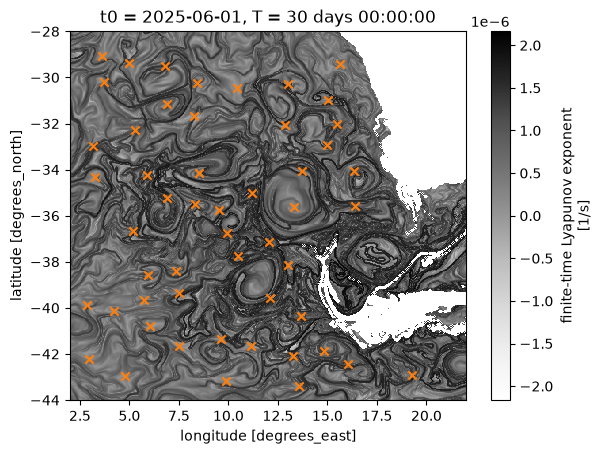

In [17]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.scatter(centre_lon, centre_lat, marker="x", color="tab:orange")
plt.show()

## Poincaré sections and the return map

A section runs due east from each candidate centre and a second runs due west,
so an orbit whose eastern arc leaves the admissible region is still found on
the western one. `first_return` walks each traced line and finds the first
crossing of a section after the line has moved away from it, linearly
interpolating the crossing longitude. Both `s` and `P(s)` are arc length from
the centre along the section, and a zero of $P(s) - s$ is a closed orbit.

In [18]:
SECTION_LENGTH_M = 250_000.0
N_LAUNCH = 50
STEP_M = 2_000.0
RING_DIAMETER_M = 300_000.0  # the largest ring size this box targets
BUDGET_M = 2 * np.pi * (RING_DIAMETER_M / 2) * 2  # two circumferences
N_STEPS = round(BUDGET_M / STEP_M)
LAMBDAS = np.arange(0.80, 2.00 + 1e-9, 0.04)
SIGNS = [+1, -1]
DIRECTIONS = [+1, -1]  # east, west
CLOSE_TOL_M = 2_000.0


def section_points(*, centre_lon, centre_lat, length_m, n, direction):
    """Launch points along the section running east (+1) or west (-1)."""
    s = np.linspace(0.0, length_m, n)
    lon = centre_lon + direction * s / (_M_PER_DEG * np.cos(np.deg2rad(centre_lat)))
    lat = np.full(n, centre_lat)
    return s, lon, lat


def section_arc_length(lon, *, centre_lon, centre_lat, direction):
    """Arc length from the centre along the section, positive along it."""
    return direction * (lon - centre_lon) * _M_PER_DEG * np.cos(np.deg2rad(centre_lat))


def first_return(
    *, track_lon, track_lat, section_lat, section_lon_min, section_lon_max
):
    """First crossing of the section segment after the line has moved off it.

    Returns the crossing longitude, NaN where the line never comes back, and
    the number of track points up to and including the crossing step.

    A line encircling the centre also crosses the section latitude on the far
    side, outside the segment. That is not a return, and the scan runs on.
    """
    n_steps_p1, n_lines = track_lon.shape
    north_rel = track_lat - section_lat
    result_lon = np.full(n_lines, np.nan)
    cut = np.full(n_lines, n_steps_p1, dtype=int)
    for k in range(n_lines):
        lon_k, rel_k = track_lon[:, k], north_rel[:, k]
        started_away = False
        for i in range(1, n_steps_p1):
            if not (np.isfinite(rel_k[i]) and np.isfinite(lon_k[i])):
                break
            if not started_away:
                started_away = abs(rel_k[i]) > 1e-9
                continue
            if rel_k[i - 1] == 0 or (np.sign(rel_k[i - 1]) != np.sign(rel_k[i])):
                t = rel_k[i - 1] / (rel_k[i - 1] - rel_k[i])
                lon_cross = lon_k[i - 1] + t * (lon_k[i] - lon_k[i - 1])
                if section_lon_min - 1e-6 <= lon_cross <= section_lon_max + 1e-6:
                    result_lon[k], cut[k] = lon_cross, i + 1
                    break
    return result_lon, cut

## Closed orbits over all $\lambda$, signs and sections

For every candidate centre, every $\lambda$, each sign of $\eta_\lambda$ and
each section, the sweep finds the sign changes of $P(s) - s$ across
neighbouring launch points, refines each by linear interpolation, re-traces
from the refined $s$, and accepts it as a closed orbit when the residual return
displacement is under `CLOSE_TOL_M`.

A residual-only check accepts a line that merely grazes back across the
section without enclosing the centre, so every candidate also has to enclose
the centre and have a circumference within a factor of 2 of $2\pi r$ for its
mean radius $r$.

The sweep also records, for each combination, how far around the centre its
best launch point gets before the line ends. A closed orbit needs a full
revolution, so that number bounds what the search can find.

In [19]:
def revolutions(*, track_lon, track_lat, centre_lon, centre_lat):
    """Turns each traced line makes about the centre before it terminates."""
    dx, dy = _separation_m(
        lon_a=centre_lon, lat_a=centre_lat, lon_b=track_lon, lat_b=track_lat
    )
    angle = np.unwrap(np.arctan2(dy, dx), axis=0)
    turns = np.full(track_lon.shape[1], np.nan)
    for k in range(track_lon.shape[1]):
        finite = np.isfinite(angle[:, k])
        if finite.sum() > 1:
            ends = angle[finite, k]
            turns[k] = (ends[-1] - ends[0]) / (2 * np.pi)
    return turns

In [20]:
def sweep_centres(*, centre_lon, centre_lat, lambdas, signs, tensor_interp):
    """Closed-orbit search over every candidate centre, lambda, sign and section."""
    closed_orbits = []
    winding = []
    n_never_return = 0

    for ci, (cl, ca) in enumerate(zip(centre_lon, centre_lat, strict=True)):
        for direction in DIRECTIONS:
            s_vals, launch_lon, launch_lat = section_points(
                centre_lon=cl,
                centre_lat=ca,
                length_m=SECTION_LENGTH_M,
                n=N_LAUNCH,
                direction=direction,
            )
            lon_min, lon_max = launch_lon.min(), launch_lon.max()
            for lam in lambdas:
                for sign in signs:
                    track_lon, track_lat = trace_eta_lines(
                        lon_0=launch_lon,
                        lat_0=launch_lat,
                        lam=lam,
                        sign=sign,
                        step_m=STEP_M,
                        n_steps=N_STEPS,
                        tensor_interp=tensor_interp,
                    )
                    turns = revolutions(
                        track_lon=track_lon,
                        track_lat=track_lat,
                        centre_lon=cl,
                        centre_lat=ca,
                    )
                    if np.isfinite(turns).any():
                        k_best = int(np.nanargmax(np.abs(turns)))
                        winding.append(
                            {
                                "centre_idx": ci,
                                "centre_lon": cl,
                                "centre_lat": ca,
                                "direction": direction,
                                "lam": lam,
                                "sign": sign,
                                "s": s_vals[k_best],
                                "turns": turns[k_best],
                                "steps": int(np.isfinite(track_lon[:, k_best]).sum()),
                            }
                        )
                    ret_lon, _ = first_return(
                        track_lon=track_lon,
                        track_lat=track_lat,
                        section_lat=ca,
                        section_lon_min=lon_min,
                        section_lon_max=lon_max,
                    )
                    ret_s = section_arc_length(
                        ret_lon, centre_lon=cl, centre_lat=ca, direction=direction
                    )
                    if not np.isfinite(ret_s).any():
                        n_never_return += 1
                        continue
                    P_minus_s = ret_s - s_vals
                    finite = np.isfinite(P_minus_s)
                    for i in range(N_LAUNCH - 1):
                        if not (finite[i] and finite[i + 1]):
                            continue
                        a, b = P_minus_s[i], P_minus_s[i + 1]
                        if not (a == 0 or np.sign(a) != np.sign(b)):
                            continue
                        t = a / (a - b)
                        s_fix = s_vals[i] + t * (s_vals[i + 1] - s_vals[i])
                        dlon = direction * s_fix / (_M_PER_DEG * np.cos(np.deg2rad(ca)))
                        poly_lon, poly_lat = trace_eta_lines(
                            lon_0=np.array([cl + dlon]),
                            lat_0=np.array([ca]),
                            lam=lam,
                            sign=sign,
                            step_m=STEP_M,
                            n_steps=N_STEPS,
                            tensor_interp=tensor_interp,
                        )
                        ret_lon2, cut_arr = first_return(
                            track_lon=poly_lon,
                            track_lat=poly_lat,
                            section_lat=ca,
                            section_lon_min=lon_min,
                            section_lon_max=lon_max,
                        )
                        if not np.isfinite(ret_lon2[0]):
                            continue
                        ret_s2 = section_arc_length(
                            ret_lon2[0],
                            centre_lon=cl,
                            centre_lat=ca,
                            direction=direction,
                        )
                        residual_m = abs(ret_s2 - s_fix)
                        if residual_m >= CLOSE_TOL_M:
                            continue
                        cut = int(cut_arr[0])
                        dx, dy = _separation_m(
                            lon_a=cl,
                            lat_a=ca,
                            lon_b=poly_lon[:cut, 0],
                            lat_b=poly_lat[:cut, 0],
                        )
                        radius_m = np.hypot(dx, dy)
                        mean_radius_m = float(np.nanmean(radius_m))
                        encloses = MplPath(np.column_stack([dx, dy])).contains_point(
                            (0.0, 0.0)
                        )
                        length_m = np.sum(
                            np.hypot(
                                np.diff(np.append(dx, dx[0])),
                                np.diff(np.append(dy, dy[0])),
                            )
                        )
                        circumference_ratio = (
                            length_m / (2 * np.pi * mean_radius_m)
                            if mean_radius_m > 0
                            else np.nan
                        )
                        closed_orbits.append(
                            {
                                "centre_idx": ci,
                                "centre_lon": cl,
                                "centre_lat": ca,
                                "direction": direction,
                                "lam": lam,
                                "sign": sign,
                                "s": s_fix,
                                "residual_m": residual_m,
                                "lon": poly_lon[:cut, 0],
                                "lat": poly_lat[:cut, 0],
                                "mean_radius_m": mean_radius_m,
                                "encloses_centre": bool(encloses),
                                "circumference_ratio": float(circumference_ratio),
                            }
                        )
    return closed_orbits, winding, n_never_return

In [21]:
def keep_closed(candidates):
    """The candidates that enclose their centre and have a plausible shape."""
    return [
        o
        for o in candidates
        if o["encloses_centre"] and 0.5 < o["circumference_ratio"] < 2.0
    ]

In [22]:
candidate_returns, winding, n_never_return = sweep_centres(
    centre_lon=centre_lon,
    centre_lat=centre_lat,
    lambdas=LAMBDAS,
    signs=SIGNS,
    tensor_interp=tensor_interp,
)
closed_orbits = keep_closed(candidate_returns)
len(candidate_returns), len(closed_orbits), n_never_return

(19, 7, 3146)

How far around its centre the best launch point gets, at each centre, largest
first. A closed orbit needs a full turn. A track holding `N_STEPS + 1` points
ran out of step budget.

In [23]:
def deepest_per_centre(records):
    """The record of largest |turns| at each centre, largest first."""
    best_per_centre = {}
    for record in records:
        ci = record["centre_idx"]
        if ci not in best_per_centre or abs(record["turns"]) > abs(
            best_per_centre[ci]["turns"]
        ):
            best_per_centre[ci] = record
    return sorted(best_per_centre.values(), key=lambda r: abs(r["turns"]), reverse=True)

In [24]:
def winding_table(records):
    return [
        (
            round(r["centre_lon"], 2),
            round(r["centre_lat"], 2),
            round(abs(r["turns"]), 2),
            r["steps"],
        )
        for r in deepest_per_centre(records)
    ]


N_STEPS + 1, winding_table(winding)

(943,
 [(np.float64(13.32), np.float64(-35.64), np.float64(11.79), 943),
  (np.float64(2.88), np.float64(-39.88), np.float64(1.01), 29),
  (np.float64(13.0), np.float64(-30.28), np.float64(0.92), 34),
  (np.float64(3.72), np.float64(-30.2), np.float64(0.89), 22),
  (np.float64(10.44), np.float64(-30.44), np.float64(0.86), 82),
  (np.float64(15.64), np.float64(-29.4), np.float64(0.82), 64),
  (np.float64(3.28), np.float64(-34.32), np.float64(0.81), 41),
  (np.float64(6.04), np.float64(-40.8), np.float64(0.81), 88),
  (np.float64(9.88), np.float64(-43.16), np.float64(0.73), 23),
  (np.float64(4.24), np.float64(-40.12), np.float64(0.73), 58),
  (np.float64(2.96), np.float64(-42.2), np.float64(0.71), 298),
  (np.float64(8.52), np.float64(-34.16), np.float64(0.68), 14),
  (np.float64(13.72), np.float64(-34.08), np.float64(0.67), 65),
  (np.float64(3.64), np.float64(-29.08), np.float64(0.63), 82),
  (np.float64(11.16), np.float64(-41.64), np.float64(0.58), 6),
  (np.float64(6.92), np.float64

## Outermost orbit per centre

The outermost closed orbit, by mean radius, marks the vortex boundary at each
centre that has one.

In [25]:
def outermost_per_centre(orbits):
    """The largest-mean-radius closed orbit at each centre."""
    outermost = {}
    for o in orbits:
        ci = o["centre_idx"]
        if ci not in outermost or o["mean_radius_m"] > outermost[ci]["mean_radius_m"]:
            outermost[ci] = o
    return outermost


outermost = outermost_per_centre(closed_orbits)
len(outermost)

1

Every closed orbit that survived the filters, innermost first, as centre
longitude, centre latitude, $\lambda$, sign, section direction, mean radius in
km, circumference ratio and return residual in metres.

In [26]:
[
    (
        round(o["centre_lon"], 2),
        round(o["centre_lat"], 2),
        round(o["lam"], 3),
        o["sign"],
        o["direction"],
        round(o["mean_radius_m"] / 1000, 1),
        round(o["circumference_ratio"], 3),
        round(o["residual_m"], 1),
    )
    for o in sorted(closed_orbits, key=lambda o: o["mean_radius_m"])
]

[(np.float64(13.32),
  np.float64(-35.64),
  np.float64(1.2),
  1,
  1,
  26.9,
  1.013,
  np.float64(180.1)),
 (np.float64(13.32),
  np.float64(-35.64),
  np.float64(1.2),
  1,
  -1,
  30.9,
  1.004,
  np.float64(639.9)),
 (np.float64(13.32),
  np.float64(-35.64),
  np.float64(1.2),
  1,
  1,
  31.6,
  1.013,
  np.float64(903.3)),
 (np.float64(13.32),
  np.float64(-35.64),
  np.float64(1.24),
  1,
  1,
  33.5,
  1.028,
  np.float64(1773.6)),
 (np.float64(13.32),
  np.float64(-35.64),
  np.float64(1.24),
  1,
  -1,
  35.4,
  1.01,
  np.float64(165.8)),
 (np.float64(13.32),
  np.float64(-35.64),
  np.float64(1.28),
  1,
  1,
  37.3,
  1.032,
  np.float64(420.3)),
 (np.float64(13.32),
  np.float64(-35.64),
  np.float64(1.28),
  1,
  -1,
  37.7,
  1.013,
  np.float64(98.3))]

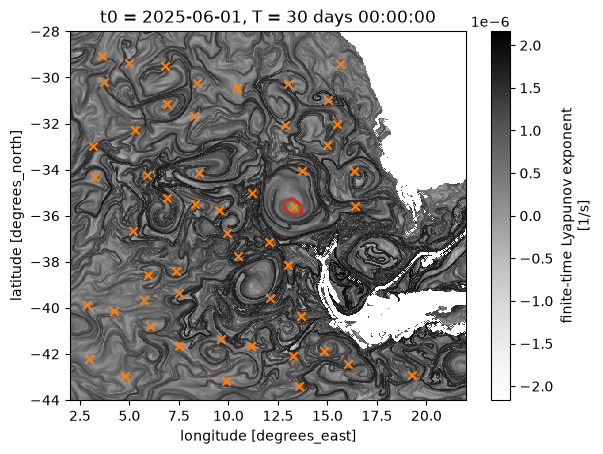

In [27]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.scatter(centre_lon, centre_lat, marker="x", color="tab:orange")
for o in closed_orbits:
    ax.plot(
        o["lon"],
        o["lat"],
        "-" if o["sign"] > 0 else "--",
        color="tab:green",
        lw=0.7,
        alpha=0.6,
    )
for o in outermost.values():
    ax.plot(o["lon"], o["lat"], color="tab:red", lw=2.0)
plt.show()

## The return map at the boundary's centre

$P(s) - s$ along the eastern section at the centre of the outermost orbit (or,
if none closed, at the centre whose best launch point turned furthest), on that
centre's sign of $\eta_\lambda$. A zero is a closed orbit. The $\lambda$
drawn straddle that centre's own $\lambda$, from 0.2 below it to 0.1 above.

In [28]:
if outermost:
    boundary = max(outermost.values(), key=lambda o: o["mean_radius_m"])
    best = {
        "centre_lon": boundary["centre_lon"],
        "centre_lat": boundary["centre_lat"],
        "lam": boundary["lam"],
        "sign": boundary["sign"],
        "direction": boundary["direction"],
        "s": boundary["s"],
    }
else:
    best = deepest_per_centre(winding)[0]
best["centre_lon"], best["centre_lat"], best["lam"], best["sign"]

(np.float64(13.320000000000011),
 np.float64(-35.64000000000018),
 np.float64(1.2800000000000005),
 1)

In [29]:
RETURN_MAP_LAMBDAS = [best["lam"] + d for d in (-0.2, -0.1, 0.0, 0.1)]
s_vals, launch_lon, launch_lat = section_points(
    centre_lon=best["centre_lon"],
    centre_lat=best["centre_lat"],
    length_m=SECTION_LENGTH_M,
    n=N_LAUNCH,
    direction=+1,
)
return_maps = {}
for lam in RETURN_MAP_LAMBDAS:
    track_lon, track_lat = trace_eta_lines(
        lon_0=launch_lon,
        lat_0=launch_lat,
        lam=lam,
        sign=best["sign"],
        step_m=STEP_M,
        n_steps=N_STEPS,
        tensor_interp=tensor_interp,
    )
    ret_lon, _ = first_return(
        track_lon=track_lon,
        track_lat=track_lat,
        section_lat=best["centre_lat"],
        section_lon_min=launch_lon.min(),
        section_lon_max=launch_lon.max(),
    )
    return_maps[lam] = section_arc_length(
        ret_lon,
        centre_lon=best["centre_lon"],
        centre_lat=best["centre_lat"],
        direction=+1,
    )

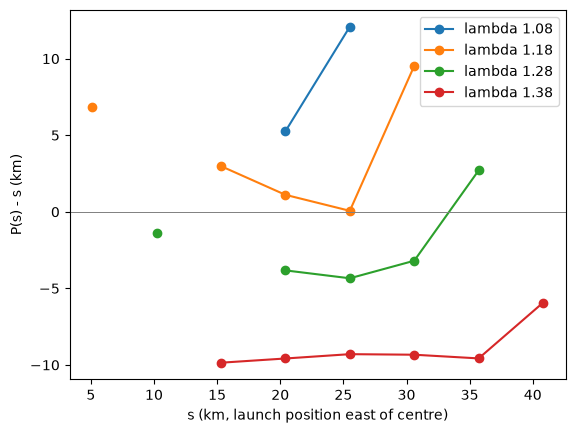

In [30]:
fig, ax = plt.subplots()
for lam, ret_s in return_maps.items():
    ax.plot(
        s_vals / 1000, (ret_s - s_vals) / 1000, marker="o", label=f"lambda {lam:.2f}"
    )
ax.axhline(0, color="grey", lw=0.7)
ax.set_xlabel("s (km, launch position east of centre)")
ax.set_ylabel("P(s) - s (km)")
ax.legend()
plt.show()

## Validation by advection

$|\nabla F\,\eta_\lambda| = \lambda$ holds pointwise, so any arc tangent to
$\eta_\lambda$ has its arc length multiplied by $\lambda$, whether or not it
closes. Advecting an arc through `flowmap.image()` (which interpolates the
flow map already computed, so no second Parcels run is needed) and
re-measuring its length checks the tangent field and the stepper against
that.

In [31]:
def arc_length_m(*, lon, lat):
    dx, dy = _separation_m(lon_a=lon[:-1], lat_a=lat[:-1], lon_b=lon[1:], lat_b=lat[1:])
    return np.sum(np.hypot(dx, dy))


def evolve_and_ratio(flowmap, *, lon, lat):
    length_0 = arc_length_m(lon=lon, lat=lat)
    evolved = flowmap.image(
        lon_0=xr.DataArray(lon, dims="point"), lat_0=xr.DataArray(lat, dims="point")
    )
    lon_1, lat_1 = evolved["lon"].values, evolved["lat"].values
    return arc_length_m(lon=lon_1, lat=lat_1) / length_0, length_0, lon_1, lat_1

The $\eta_\lambda$ lines launched along the section at that centre, drawn over
the FTLE.

In [32]:
s_vals, launch_lon, launch_lat = section_points(
    centre_lon=best["centre_lon"],
    centre_lat=best["centre_lat"],
    length_m=SECTION_LENGTH_M,
    n=N_LAUNCH,
    direction=best["direction"],
)
best_lon, best_lat = trace_eta_lines(
    lon_0=launch_lon,
    lat_0=launch_lat,
    lam=best["lam"],
    sign=best["sign"],
    step_m=STEP_M,
    n_steps=N_STEPS,
    tensor_interp=tensor_interp,
)

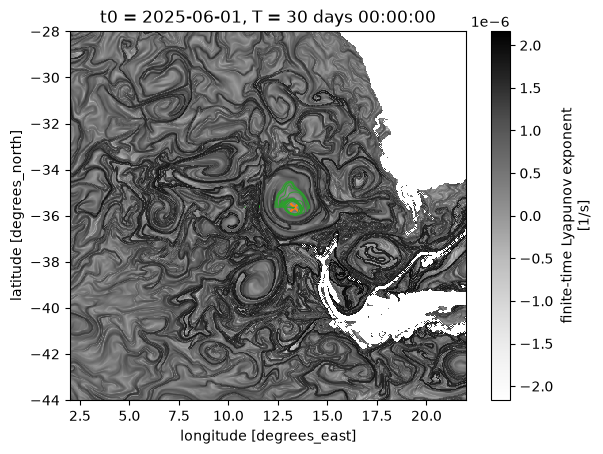

In [33]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.plot(best_lon, best_lat, color="tab:green", lw=0.7)
ax.scatter(best["centre_lon"], best["centre_lat"], marker="x", color="tab:orange")
plt.show()

Repeating the advection check for every $\lambda$ of the sweep, from the
same launch point, tests the whole family rather than one member.

In [34]:
launch_dlon = (
    best["direction"]
    * best["s"]
    / (_M_PER_DEG * np.cos(np.deg2rad(best["centre_lat"])))
)
arcs = {}
for lam in LAMBDAS:
    arc_lon, arc_lat = trace_eta_lines(
        lon_0=np.array([best["centre_lon"] + launch_dlon]),
        lat_0=np.array([best["centre_lat"]]),
        lam=lam,
        sign=best["sign"],
        step_m=STEP_M,
        n_steps=N_STEPS,
        tensor_interp=tensor_interp,
    )
    finite = np.isfinite(arc_lon[:, 0])
    if finite.sum() >= 10:
        arcs[lam] = (arc_lon[finite, 0], arc_lat[finite, 0])
ratios = {
    lam: evolve_and_ratio(forward, lon=arc[0], lat=arc[1])[0]
    for lam, arc in arcs.items()
}
ratios

{np.float64(0.8800000000000001): np.float64(0.8358285121753091),
 np.float64(0.9200000000000002): np.float64(0.8852174940950691),
 np.float64(0.9600000000000002): np.float64(0.9204835441507138),
 np.float64(1.0000000000000002): np.float64(0.9650163668017998),
 np.float64(1.0400000000000003): np.float64(1.0085303407297819),
 np.float64(1.0800000000000003): np.float64(1.0544362542040377),
 np.float64(1.1200000000000003): np.float64(1.1073836626071514),
 np.float64(1.1600000000000004): np.float64(1.1428560281582032),
 np.float64(1.2000000000000004): np.float64(1.1799760563344195),
 np.float64(1.2400000000000004): np.float64(1.1848651705128865),
 np.float64(1.2800000000000005): np.float64(1.2135071389686114),
 np.float64(1.3200000000000005): np.float64(1.2350055503880157),
 np.float64(1.3600000000000005): np.float64(1.2838633077379715),
 np.float64(1.4000000000000006): np.float64(1.3308564873539677),
 np.float64(1.4400000000000006): np.float64(1.3885898055166046),
 np.float64(1.48000000000

The measured ratio sits below its $\lambda$ up to $\lambda = 1.80$, by as
much as 7.4 percent at $\lambda = 1.48$, and up to 2.4 percent above it from
$\lambda = 1.84$ on.

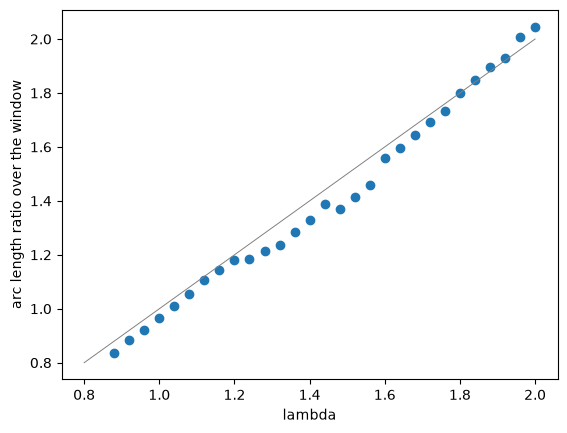

In [35]:
fig, ax = plt.subplots()
ax.plot(list(ratios), list(ratios.values()), marker="o", ls="none")
ax.plot(LAMBDAS, LAMBDAS, color="grey", lw=0.7)
ax.set_xlabel("lambda")
ax.set_ylabel("arc length ratio over the window")
plt.show()

The arc traced at the boundary's own $\lambda$, before and after the
window.

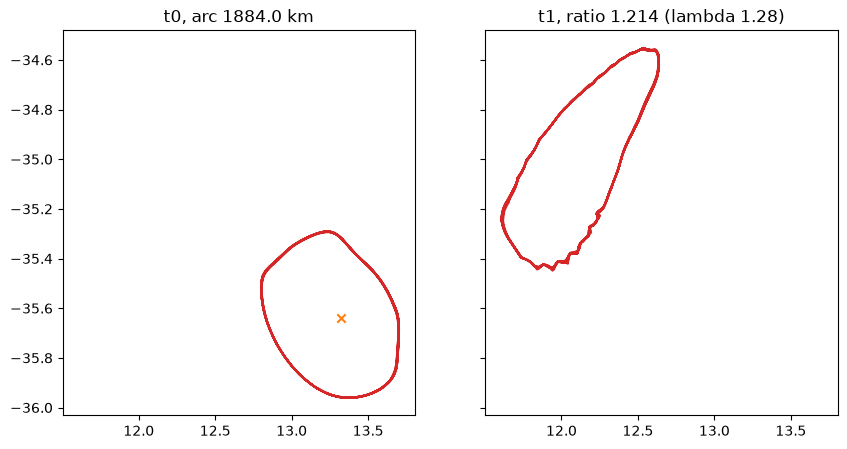

In [36]:
arc_lon, arc_lat = arcs[best["lam"]]
ratio, length_0, evolved_lon, evolved_lat = evolve_and_ratio(
    forward, lon=arc_lon, lat=arc_lat
)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax0.set_title(f"t0, arc {length_0 / 1000:.1f} km")
ax0.plot(arc_lon, arc_lat, color="tab:red")
ax0.scatter(best["centre_lon"], best["centre_lat"], marker="x", color="tab:orange")
ax1.set_title(f"t1, ratio {ratio:.3f} (lambda {best['lam']:.2f})")
ax1.plot(evolved_lon, evolved_lat, color="tab:red")
plt.show()

## Material check: the outermost boundary against a circle

The outermost orbit should stretch uniformly by its $\lambda$, so its
arc-length ratio over the window should land near that $\lambda$. A circle of
the same mean radius about the same centre is not tangent to $\eta_\lambda$,
so its arc-length ratio is not constrained to any $\lambda$. Advecting both
through `flowmap.image()` and comparing the two ratios tests that.

In [37]:
if outermost:
    boundary_lon, boundary_lat = boundary["lon"], boundary["lat"]

    theta = np.linspace(0.0, 2 * np.pi, len(boundary_lon))
    circle_lon = boundary["centre_lon"] + boundary["mean_radius_m"] * np.cos(theta) / (
        _M_PER_DEG * np.cos(np.deg2rad(boundary["centre_lat"]))
    )
    circle_lat = boundary["centre_lat"] + boundary["mean_radius_m"] * np.sin(theta) / (
        _M_PER_DEG
    )

    boundary_ratio, boundary_length_0, boundary_lon_1, boundary_lat_1 = (
        evolve_and_ratio(forward, lon=boundary_lon, lat=boundary_lat)
    )
    circle_ratio, circle_length_0, circle_lon_1, circle_lat_1 = evolve_and_ratio(
        forward, lon=circle_lon, lat=circle_lat
    )
    material_check = {
        "boundary_lambda": boundary["lam"],
        "boundary_ratio": boundary_ratio,
        "boundary_off_grid_points": int(np.isnan(boundary_lon_1).sum()),
        "circle_ratio": circle_ratio,
        "circle_off_grid_points": int(np.isnan(circle_lon_1).sum()),
    }
else:
    material_check = None
material_check

{'boundary_lambda': np.float64(1.2800000000000005),
 'boundary_ratio': np.float64(1.226621634948904),
 'boundary_off_grid_points': 0,
 'circle_ratio': np.float64(1.4670008157906573),
 'circle_off_grid_points': 0}

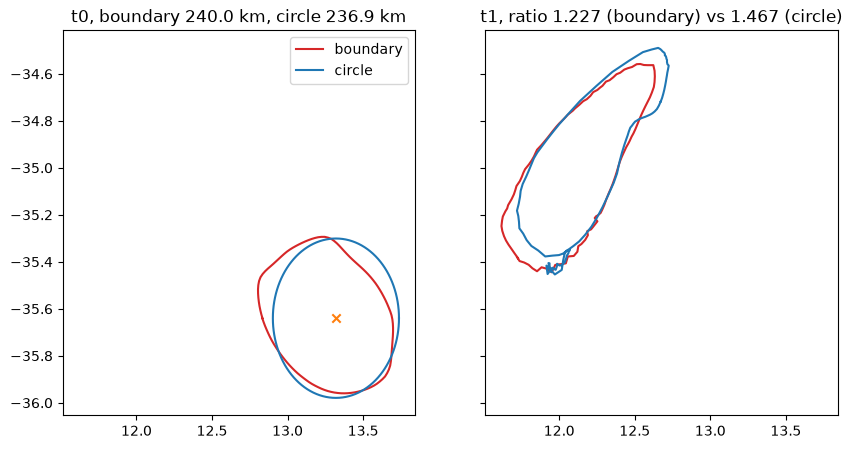

In [38]:
if outermost:
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    ax0.set_title(
        f"t0, boundary {boundary_length_0 / 1000:.1f} km, "
        f"circle {circle_length_0 / 1000:.1f} km"
    )
    ax0.plot(boundary_lon, boundary_lat, color="tab:red", label="boundary")
    ax0.plot(circle_lon, circle_lat, color="tab:blue", label="circle")
    ax0.scatter(
        boundary["centre_lon"], boundary["centre_lat"], marker="x", color="tab:orange"
    )
    ax0.legend()
    ax1.set_title(
        f"t1, ratio {boundary_ratio:.3f} (boundary) vs {circle_ratio:.3f} (circle)"
    )
    ax1.plot(boundary_lon_1, boundary_lat_1, color="tab:red")
    ax1.plot(circle_lon_1, circle_lat_1, color="tab:blue")
    plt.show()

## Outcome

The sweep closes 7 orbits at 30 days, all at one centre, 13.32 E 35.64 S, on
the $+$ branch of $\eta_\lambda$ and at $\lambda$ from 1.20 to 1.28. Their
mean radii run from 26.9 km, at $\lambda = 1.20$, to 37.7 km, at
$\lambda = 1.28$. Over the 52 candidate centres, 3146 combinations of
$\lambda$, sign and section never return to their section.

The scan runs to $\lambda = 2.00$, so the outermost orbit at
$\lambda = 1.28$ does not sit at the top of the scanned range.

Advected through the flow map, that orbit has its arc length multiplied by
1.227, against its $\lambda$ of 1.28. A circle of the same mean radius about
the same centre stretches by 1.467. Neither leaves the grid.

The arc launched from the same point stretches by less than its $\lambda$ up
to $\lambda = 1.80$, with the largest shortfall of 7.4 percent at
$\lambda = 1.48$, and by up to 2.4 percent more than its $\lambda$ above
that. Below $\lambda = 0.88$ no arc holds ten finite points.

$|\det \nabla F|$ over the window has a median of 4.96 and runs from 0.172 at
the 5 percent quantile to 675 at the 95 percent, so the area of a grid cell
changes by orders of magnitude across the box.

The best launch point anywhere turns 11.79 times about that same centre and
exhausts the 943-point step budget. Of the 501 by 401 seeded particles, 24500
are lost to land or the domain edge.